# XGBoost Multimodal Deepfake Detection Fusion

#Experiment Definitions:

E21: MFCC Vector, WER, similarity

E22: MFCC Vector, WER, mfcc_svm_decision_score

E23: WER, similarity, mfcc_svm_decision_score

E24: mfcc_prediction , mfcc_probability, mfcc_svm_decision_score

E25 (Full Fusion): MFCC Vector, similarity, WER, correct_words_#, mfcc_probability, mfcc_svm_decision_score, mfcc_prediction



## Features Index (62 Columns)



# Audio Features (Pickle):

mfcc_feat_0 to mfcc_feat_49 (50 Dimensions)

# Textual & Statistical Features (CSV):

WER (Word Error Rate)

similarity

correct_words_#

# Model Outputs & Probabilities:

mfcc_prediction

mfcc_probability

mfcc_svm_decision_score

# Identifiers & Target:

Video_ID

label (Target Class)

In [ ]:

import pandas as pd
import numpy as np
import xgboost as xgb
import pickle
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


In [ ]:
# read and load data
drive.mount('/content/drive')
df_master = pd.read_csv('/content/drive/My Drive/dataset_Master/master.csv')

with open('/content/drive/My Drive/dataset_Master/mfcc_data.pkl', 'rb') as f:
    mfcc_dict = pickle.load(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# dataframe setting

mfcc_vec_cols = [f'mfcc_feat_{i}' for i in range(50)]
mfcc_df = pd.DataFrame(mfcc_dict['mfcc_features'], columns=mfcc_vec_cols)
mfcc_df['Video_ID'] = mfcc_dict['filename']

# Clean the Video_ID to ensure consistency and proper matching

df_master['Video_ID'] = df_master['Video_ID'].astype(str).str.replace('.mp4', '', regex=False).str.strip()
mfcc_df['Video_ID'] = mfcc_df['Video_ID'].astype(str).str.replace('.mp4', '', regex=False).str.strip()

# final marge
df = pd.merge(df_master, mfcc_df, on='Video_ID', how='inner')
print(f"marge done : {len(df.columns)}")

marge done : 62


In [ ]:
# data cleaning
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [ ]:
# explor dataframe make sure all marge done well
df.head()

,Video_ID,label,similarity,WER,correct_words_#,mfcc_prediction,mfcc_probability,mfcc_svm_decision_score,mfcc_feat_0,mfcc_feat_1,...,mfcc_feat_40,mfcc_feat_41,mfcc_feat_42,mfcc_feat_43,mfcc_feat_44,mfcc_feat_45,mfcc_feat_46,mfcc_feat_47,mfcc_feat_48,mfcc_feat_49
0,0_00000,0,8.146640,100.000000,0,1,0.713175,0.782946,-236.617630,92.429817,...,1789.505629,3464.272444,1735.006472,15.691054,17.774254,21.079627,19.397982,18.500947,19.722032,18.300492
1,0_00001,0,76.973684,42.105263,23,0,0.968595,-3.215874,-407.668823,157.306702,...,2151.846035,4112.542378,2831.515993,17.229187,11.051055,15.226733,16.610441,17.618802,20.712544,30.284682
2,0_00002,0,70.625000,58.823529,15,0,0.811473,-1.412783,-272.981842,84.132591,...,1972.243099,3600.777838,1588.110604,23.540508,16.790347,18.396294,17.768354,17.482005,20.647386,16.886003
3,0_00003,0,74.183976,45.945946,20,1,0.553677,0.140833,-333.608978,99.893410,...,1788.165107,3605.878995,1670.140595,19.345279,14.418756,19.533040,17.153365,17.736857,22.227197,16.922992
4,0_00004,0,58.823529,81.250000,5,1,0.794505,1.190282,-350.967590,128.054321,...,1160.019862,2186.167636,1479.830982,21.573779,15.305312,18.890804,16.583260,18.213436,15.842405,15.238705


In [13]:
# set up the experiments in features
experiments = {
    "E21": mfcc_vec_cols + ['WER', 'similarity'],
    "E22": mfcc_vec_cols + ['WER', 'mfcc_svm_decision_score'],
    "E23": ['WER', 'similarity', 'mfcc_svm_decision_score'],
    "E24":['mfcc_prediction','mfcc_probability', 'mfcc_svm_decision_score'],
    "E25": mfcc_vec_cols + ['similarity', 'WER', 'correct_words_#',
                            'mfcc_probability', 'mfcc_svm_decision_score','mfcc_prediction']
}
results = []


In [14]:
# run experiments
for exp_name, features in experiments.items():

    # to ensure that all required features are present in the actual dataset table.
    available_features = [f for f in features if f in df.columns]

    # set x ,y
    X = df[available_features]
    y = df['label']


    # 1. First split: 80% for (Train + Val) and 20% for Testing
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Second split: From the 80%, take 25% for Validation
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)


    # 3. Model Training with Validation Set
    model = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, eval_metric='logloss')

    # Fit the model using early_stopping or just monitoring validation
    model.fit(
         X_train, y_train,
         eval_set=[(X_val, y_val)],
         verbose=False
         )

  # model testing
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]


    # get all matrix
    results.append({
        "Experiment": exp_name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4)
    })
    print(f"Done from Experiment: {exp_name}")

Done from Experiment: E21
Done from Experiment: E22
Done from Experiment: E23
Done from Experiment: E24
Done from Experiment: E25


In [15]:
# display result
results_df = pd.DataFrame(results)
display(results_df)

,Experiment,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,E21,0.9402,0.9181,0.9755,0.9459,0.9849
1,E22,0.9428,0.9263,0.9706,0.9479,0.9835
2,E23,0.8948,0.8636,0.9547,0.9069,0.9550
3,E24,0.7561,0.7615,0.7941,0.7774,0.8227
4,E25,0.9441,0.9255,0.9743,0.9493,0.9850


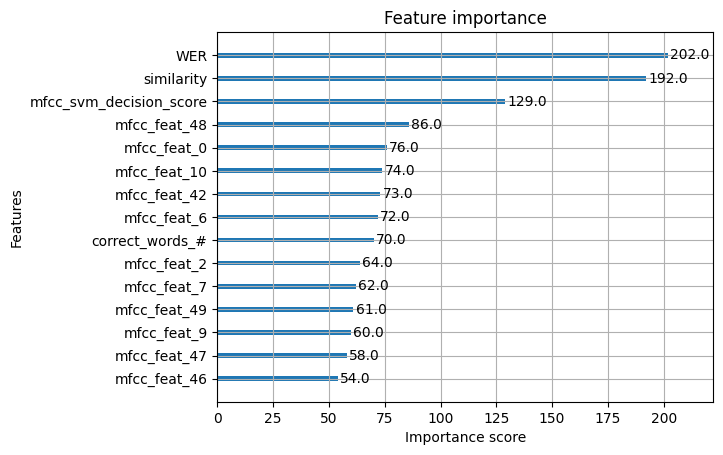

In [20]:
import matplotlib.pyplot as plt

# display the most importance features
xgb.plot_importance(model, max_num_features=15) # 15 features
plt.show()

In [ ]:
#Calculate accuracy for training and testing for overfit and underfittingcheck

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")


diff = train_acc - test_acc
if diff > 0.10:
    print(" Warning: Potential Overfitting! (Large gap)")
elif train_acc < 0.70:
    print(" Warning: Potential Underfitting! (Low overall accuracy)")
else:
    print(" Model looks well-balanced.")

Training Accuracy: 0.9961
Testing Accuracy: 0.9441
 Model looks well-balanced.
